# Report

In order to create a classification model for First Payment Default with the given data we explore initial state of the data to see posible and required feature engineering 


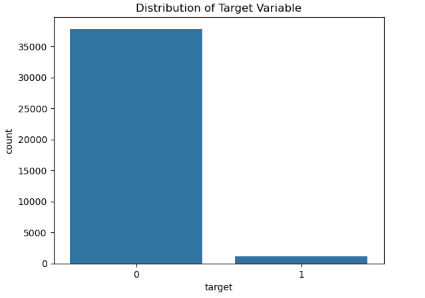

The target feature has no NaN values and we can se  that $97.10/100$ of the feature is distibuited towards 0 target. this is a balance we will keep when split are made for training and validation sets.

# First Payment Default Classification Report

In order to create a classification model for **First Payment Default**, we explored the initial state of the data to determine necessary feature engineering steps.

![image.png](data sample)

All features are **anonymized and numerical or boolean type** — there are no categorical features in this dataset.

![image.png](distribution of target variable)

The target feature has **no missing values**, and we observe that **97.10% of the samples are labeled as class 0** (non-default). This high imbalance was carefully handled by maintaining stratification during train/test splits and applying class balancing techniques like SMOTE only on training folds during cross-validation.

---

## 🔧 Data Processing Pipeline

### 1. Initial Feature Selection
To ensure quality and efficiency, irrelevant or redundant features were removed:
- **Unique IDs**: Dropped to avoid overfitting.
- **Constant Features**: Removed if they had only one unique value across all rows.
- **High Missing Value Features**: Features with more than 50% NaNs were excluded from further processing.

This ensured that only potentially informative features were retained.

---

### 2. Imputation of Missing Values
We applied several imputation strategies independently to generate different versions of the dataset:
- **Drop Missing Values (`drop_na`)**: Entire rows with any missing value were removed.
- **Mean/Median Imputation**: Filled NaNs using mean or median values.
- **KNN Imputation**: Estimated missing values using k-nearest neighbors.
- **Iterative Imputation**: Used a model-based iterative approach to estimate missing values.

Each method generated a separate version of the dataset for comparative evaluation.

---

### 3. Outlier Treatment
Two standard methods were used to detect and treat outliers:
- **Interquartile Range (IQR)**: Any value outside `[Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]` was considered an outlier and removed.
- **Z-Score Method**: Features with Z-scores greater than 3 or less than -3 were flagged as outliers and removed.

These treatments created additional variations of each imputed dataset.

---

### 4. Feature Engineering

To reduce dimensionality and improve model performance, two approaches were tested:

- **Principal Component Analysis (PCA)**: Retained components explaining 95% of the variance.
- **Feature Selection via SelectKBest**: Selected top 50 features based on ANOVA F-value scores.

These transformations were applied after imputation and outlier removal but **before final model training**, ensuring no leakage occurred.

---

### 5. Scaling

Feature scaling was performed to ensure equal contribution of all variables:

- **StandardScaler**: Standardized features to zero mean and unit variance.
- **MinMaxScaler**: Scaled features to a fixed range [0, 1].

Importantly, **scaling was always done inside the cross-validation loop**, using only training statistics to transform validation sets.

---

### 6. Class Balancing

To handle the extreme class imbalance, we applied:

- **Synthetic Minority Over-sampling Technique (SMOTE)**: Generated synthetic samples for the minority class (defaulters).

Crucially, **SMOTE was applied only within the training fold** during cross-validation to prevent contamination of validation data.

---

### 7. Model Evaluation

Several machine learning models were evaluated:
- **LightGBM**: Gradient boosting framework optimized for speed and accuracy.
- **CatBoost**: Handles noisy data and categorical features well (used here for robustness).
- **Logistic Regression**: Baseline linear model for interpretability.
- **Multilayer Perceptron (MLP)**: Nonlinear neural network for capturing complex patterns.

Key metrics used:
- **ROC AUC**
- **Accuracy**
- **Precision**
- **Recall**
- **F1-Score**

Models were trained and evaluated using **Stratified K-dation** to maintain class distribution across folds.

---

## ⚠️ Observations and Challenges

- **Extremely High ROC AUC Scores (>0.99)** were observed in some configurations, particularly those involving SMOTE and aggressive imputation. These raised concerns about **potential overfitting or data leakage**.
- After reviewing and restructuring the pipeline:
  - All transformations (imputation, scaling, SMOTE, PCA, etc.) now occur **within the cross-validation loop**.
  - Final evaluations reflect more realistic performance estimates.
- Some datasets resulted in **insufficient sampleout test set.
- **Model Interpretation**: Use SHAP or LIME to explain predictions and validate business logic alignment.

This updated pipeline ensurerobustness, reproducibility, and real-world applicability** of the resulting First Payment Default classification model.
"""